In [2]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
# os.chdir('D:/thesis_code/keypoint_matcher')
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import math


# torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

In [6]:
threshold = 75

# CSV Maker

=> Error statistics:
{'count_above_threshold_target_error': 315,
 'count_above_threshold_x': 271,
 'count_above_threshold_y': 27,
 'max_reference_error': 336.12,
 'max_target_error': 514.73,
 'mean_reference_error': 22.89,
 'mean_target_error': 2.41,
 'median_reference_error': 17.67,
 'median_target_error': 0.86,
 'min_reference_error': 0.0,
 'min_target_error': 0.0,
 'std_dev_reference_error': 19.68,
 'std_dev_target_error': 7.43}
=> Estimate Accuracy percentages:
Accuracy within 90 pixels: 99.90%
Accuracy within 60 pixels: 99.69%
Accuracy within 30 pixels: 98.72%
Accuracy within 25 pixels: 98.32%
Accuracy within 5 pixels: 92.77%
Accuracy within 2 pixels: 79.56%
Accuracy within 1.5 pixels: 71.50%
Accuracy within 1.25 pixels: 65.22%
Accuracy within 1 pixels: 56.45%
=> Number of high-error rows per dataset:
dataset
MOO02_hand_puncher_2       124
MOO04_hand_shooter_hard    107
MOO01_hand_puncher_1        62
MOO03_hand_shooter_easy     19
MOO08_mapping_hard           3
=> Correlation resu

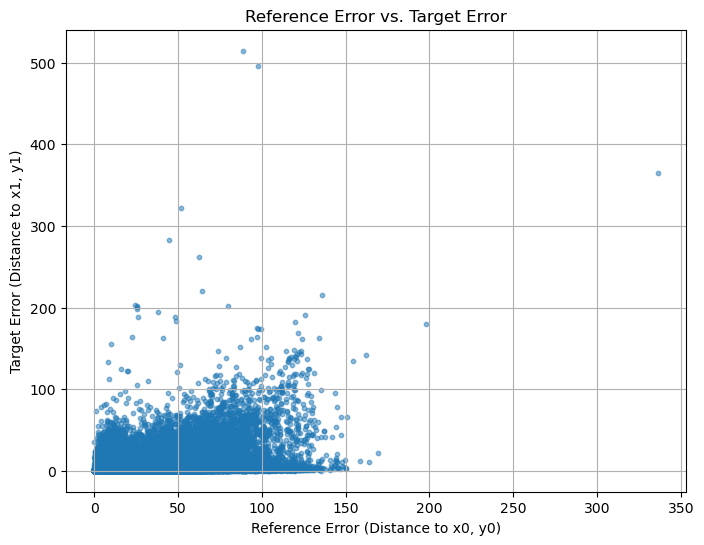

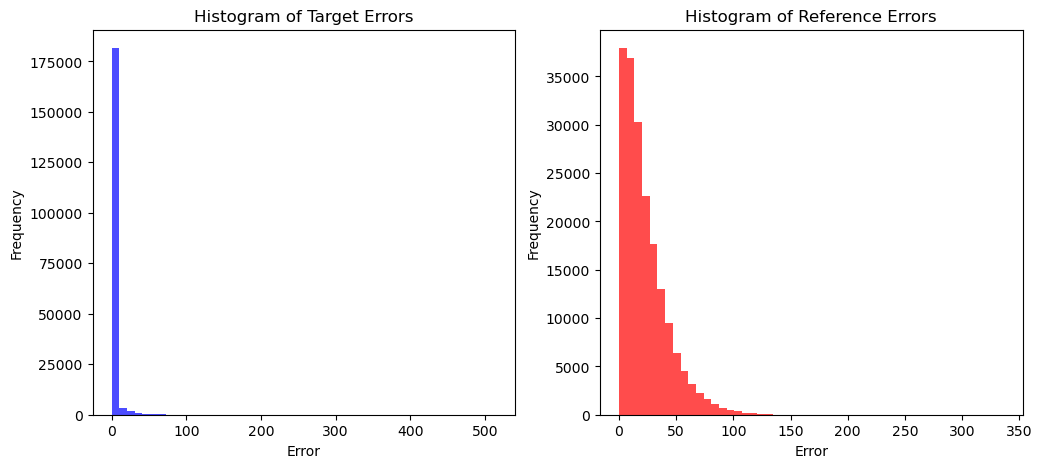

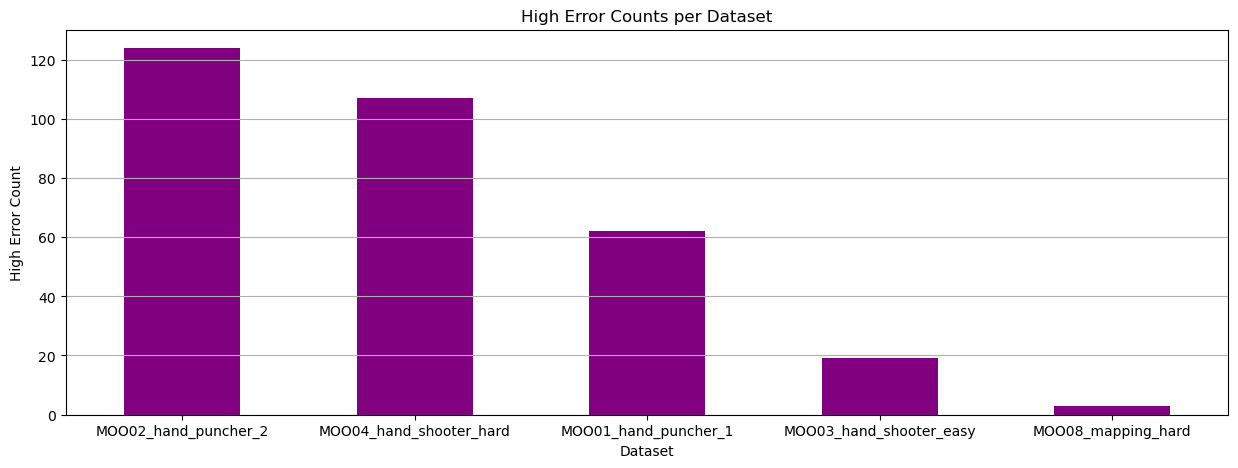

Done!


In [7]:
from distance_to_target import main

main(threshold)

In [9]:
from create_splits import main

main(threshold)

=> Dataset Stats:
Train dataset size: 136634 (72.60%)
Validation dataset size: 49933 (26.53%)
Test dataset size: 1637 (0.87%)
Total cleaned dataset size: 188204 (100%)
Done!


# Workspace

In [ ]:
from PIL import ImageDraw

def draw_circle(image, x, y, radius=5, color="red"):
    draw = ImageDraw.Draw(image)
    draw.ellipse((x - radius, y - radius, x + radius, y + radius), outline=color, width=2)
    return image


def draw_square(image, x, y, size=10, color="blue"):
    draw = ImageDraw.Draw(image)
    half = size // 2
    draw.rectangle((x - half, y - half, x + half, y + half), outline=color, width=2)
    return image

In [5]:
df = pd.read_csv(
    "training.csv",
    header=0,
    names=(
        "dataset",
        "cam",
        "kpid",
        "pair_name",
        "x0", "y0",
        "x1", "y1",
        "x_guess", "y_guess",
        "certainty",
    )
)

,dataset,cam,kpid,pair_name,x0,y0,x1,y1,x_guess,y_guess,certainty
0,MOO11_short_3_backandforth,0,1.0,8989014683290_8989047971790,161.536392,290.211517,161.276184,290.524109,161.528809,290.178772,0.587604
1,MOO11_short_3_backandforth,0,61.0,8989047971790_8989081263190,328.199493,72.053383,328.310486,72.946960,328.196564,72.025696,0.159777
2,MOO11_short_3_backandforth,0,63.0,8989114550790_8989147840590,473.058411,274.744171,473.134338,274.571686,473.051544,274.750977,0.985908
3,MOO11_short_3_backandforth,0,70.0,8989114550790_8989147840590,209.226028,122.872673,209.637497,122.533905,209.211838,122.869713,0.444692
4,MOO11_short_3_backandforth,0,71.0,8989114550790_8989147840590,238.873779,200.832397,238.450012,200.493927,238.858780,200.831268,0.948312


In [161]:
random_row = df.iloc[60, :].values

[
    DATASET,
    cam,
    kpid,
    pair_name,
    x0, y0,
    x1, y1,
    x_guess, y_guess,
    certainty
] = random_row

x0, y0, x1, y1, x_guess, y_guess = round(x0, 2), round(y0, 2), round(x1, 2), round(y1, 2), round(x_guess, 2), round(y_guess, 2)

ref_keypoint = (x0, y0)
tar_keypoint = (x1, y1)
guess_keypoint = (x_guess, y_guess)

In [162]:
left_name = pair_name.split("_")[0]
right_name = pair_name.split("_")[1]

image_a_path = f"D:/thesis_code/datasets/monado_slam/{DATASET}/mav0/cam{cam}/data/{left_name}.png"
image_b_path = f"D:/thesis_code/datasets/monado_slam/{DATASET}/mav0/cam{cam}/data/{right_name}.png"